# 06 · Guardrails: límite de llamadas y verificación XBRL

**Objetivo:** Cortar los bucles con un límite de llamadas y verificar las cifras de la respuesta contra XBRL, devolviendo el desajuste al modelo.

**Requisitos:** R04, R05, R14 ([01](../docs/01_requisitos_y_contratos.md)) · **Guía:** [09](../docs/09_skill_guardrails_middleware_xbrl.md) · teoría: [05 §6](../docs/05_teoria_agentes_react_tools.md)

**Entradas:** `data/corpus/xbrl_facts.parquet` · **Salidas:** código en `src/agente10k/guardrails.py`

**Independiente:** se ejecuta solo, sin ejecutar antes otros notebooks: lee `data/` y lo guardado en `resultados/`. Con `EJECUTAR = False` no llama a la API.

## Qué protege cada guardrail (docs/09 §1)

| Guardrail | Contra qué | Si salta |
| --- | --- | --- |
| `ToolCallLimitMiddleware(run_limit=8)` | Bucle de llamadas a herramientas (celda 23 del material de sesión 1) | Bloquea la llamada con "Tool call limit exceeded" y el modelo puede rendirse |
| `ToolCallLimitMiddleware(read_section, run_limit=1)` | Leer una sección entera sin freno (hasta ~35.000 tokens cada una) | Ídem, solo para `read_section` |
| `ModelCallLimitMiddleware(run_limit=10, exit_behavior="end")` | Un modelo que ignora los avisos anteriores | Corte duro: el grafo termina y `GuardrailsFinal.after_agent` rescata una respuesta del ledger |
| `GuardrailsFinal` — verificador XBRL (R05) | Cifras mal copiadas, escaladas, de otro ejercicio o sacadas de la prosa sin respaldo | 1 reintento con el desajuste exacto; si sigue mal, degradación honesta |
| `GuardrailsFinal` — cita por frase numerada | Citas inventadas o mal ubicadas | Reintento pidiendo `frase_ids`; sin evidencia verificada, `fuente` cae a `texto`/`ninguna` |
| `GuardrailsFinal` — abstención ante huecos (R14) | Estimar o derivar un dato que la herramienta dijo que no existe | `fuente="ninguna"`, sin cifras ni verbos de estimación en la prosa |

## Qué hace este notebook

Todo el código de aquí abajo es **determinista y sin red**: ninguna celda llama a OpenRouter ni a ningún LLM real, con `EJECUTAR` en `True` o en `False`. Donde hace falta un "modelo" para mover el agente se usa `GenericFakeChatModel` de LangChain (un guion de mensajes fijado de antemano, igual que en `tests/test_guardrails_middleware.py`); donde hace falta un dato, se llama a la herramienta real (`get_xbrl_fact`) sobre el parquet del corpus, también sin red.

1. **§1 Tope de llamadas (R04):** un modelo simulado que insiste en pedir la misma herramienta — el bucle de la celda 23 — con y sin `guardrails.middleware_final()`.
2. **§2 Verificador XBRL (R05):** `extraer_cifras` y tres casos reales de `tests/test_guardrails_verificador.py` contrastados contra el parquet real del corpus: cifra declarada por el modelo → cifra verificada.
3. **§3 Honestidad ante huecos (R14):** el hueco real del golden `golden/golden_huecos.jsonl` (`g3-h001`, margen bruto de AMZN en FY2025) — la herramienta real dice "no reportó" y el guardrail impide que la respuesta invente un porcentaje.
4. **§4 Cierre:** tabla de qué requisitos quedan cubiertos, con qué test, y qué sigue pendiente (la medición oficial del sistema `final`, que corre aparte con `evaluar(..., etiqueta="final", sistema="final")`).


In [1]:
# Arranque (igual en todos los notebooks): localiza la raíz del repo y hace importable src/
import sys, pathlib
RAIZ = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(RAIZ / "src"))
from agente10k import config

In [2]:
# Parámetros
EJECUTAR = False  # True: llama al modelo (gasta API y pide clave). False: reutiliza lo guardado en resultados/
if EJECUTAR:
    assert config.cargar_clave(), "Falta OPENROUTER_API_KEY: copia .env.example a .env y rellénala"

In [3]:
# Piezas comunes a las demos de §1 y §3: un modelo FALSO (GenericFakeChatModel, sin red) que
# ejecuta un guion de mensajes fijado de antemano, y una herramienta search_filings de juguete
# (mismo patrón que tests/test_guardrails_middleware.py). get_xbrl_fact, read_section y
# list_available SÍ son las reales: leen data/corpus/, no llaman a ningún modelo.
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy
from langchain.messages import AIMessage, ToolMessage
from langchain.tools import tool
from langchain_core.language_models.fake_chat_models import GenericFakeChatModel
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.errors import GraphRecursionError

from agente10k import guardrails as g
from agente10k.agente import RespuestaFinanciera
from agente10k.herramientas import get_xbrl_fact, list_available, read_section

COLOR_SIN = "#c0392b"   # sin guardrail: rojo
COLOR_CON = "#1f8a4c"   # con guardrail: verde
COLOR_NEUTRO = "#4472c4"


@tool
def search_filings_doble(query: str, ticker: str | None = None, fiscal_year: int | None = None,
                         item: str | None = None, k: int = 5) -> str:
    """Doble de prueba de search_filings: no consulta ningún índice ni modelo."""
    return ("[MSFT-2025-1A-0004] MSFT FY2025 Item 1A · similitud 0.9\n"
            "Texto de relleno para la demo, sin relación con las preguntas numéricas de este notebook.")


class ModeloDeGuion(GenericFakeChatModel):
    """GenericFakeChatModel que cuenta sus llamadas; acepta bind_tools() como create_agent lo exige."""

    n: int = 0

    def bind_tools(self, tools, **kw):
        return self

    def _generate(self, messages, *a, **k):
        object.__setattr__(self, "n", self.n + 1)
        return super()._generate(messages, *a, **k)


def tc(nombre: str, args: dict, i: int) -> AIMessage:
    """Un AIMessage con una única tool_call, como en tests/test_guardrails_middleware.py."""
    return AIMessage(content="", tool_calls=[{"name": nombre, "args": args, "id": f"c{i}"}])


def respuesta_final(i: int, **kw) -> AIMessage:
    """El AIMessage con el que el modelo de guion 'llama' a la tool sintética RespuestaFinanciera."""
    return tc("RespuestaFinanciera", {"respuesta": "x", "fuente": "xbrl", **kw}, i)


def correr_agente(mensajes, *, middleware, recursion_limit: int = 100, pregunta: str = "pregunta de demo"):
    """Agente real (create_agent) con el modelo de guion y las herramientas reales/dobles.

    Devuelve (resultado_o_None, modelo). Si el grafo se queda sin pasos (GraphRecursionError),
    se captura para poder mostrar cuántas llamadas hizo el modelo antes del corte.
    """
    modelo = ModeloDeGuion(messages=iter(mensajes))
    agente_demo = create_agent(
        model=modelo, tools=[get_xbrl_fact, search_filings_doble, read_section, list_available],
        response_format=ToolStrategy(schema=RespuestaFinanciera), middleware=middleware,
        checkpointer=InMemorySaver())
    cfg = {"configurable": {"thread_id": f"demo-{id(modelo)}"}, "recursion_limit": recursion_limit}
    try:
        resultado = agente_demo.invoke({"messages": [{"role": "user", "content": pregunta}]}, config=cfg)
    except GraphRecursionError:
        resultado = None
    return resultado, modelo

## 1. Tope de llamadas (R04): el bucle del margen bruto de Amazon

`AMZN` no reportó `GrossProfit` en el corpus (es uno de los huecos de `golden/golden_huecos.jsonl`). Un modelo que no sepa rendirse puede insistir
para siempre alternando el ejercicio fiscal — el bucle de la celda 23 del material de sesión 1. La demo reproduce ese guion exacto
(`tests/test_guardrails_middleware.py::test_modelo_que_siempre_pide_herramientas_termina_con_respuesta_rescatada`) con y sin la pila de
`guardrails.middleware_final()`.

Guía: [09 §2](../docs/09_skill_guardrails_middleware_xbrl.md)

In [4]:
AMZN_GROSS = {"ticker": "AMZN", "fiscal_year": 2025, "concept": "GrossProfit"}
PREGUNTA_BUCLE = "¿Cuál fue el margen bruto de AMZN en el ejercicio fiscal 2025?"


def bucle_infinito():
    """El modelo pide SIEMPRE get_xbrl_fact, alternando el ejercicio: nunca produce RespuestaFinanciera."""
    i = 0
    while True:
        i += 1
        yield tc("get_xbrl_fact", {**AMZN_GROSS, "fiscal_year": 2024 if i % 2 else 2025}, i)


# SIN guardrails: solo el arnés (recursion_limit=100, igual que el baseline). El modelo nunca se
# rinde, así que el grafo corta por recursion_limit con GraphRecursionError (sin middleware, cada
# vuelta cuesta ~2 pasos: se agotan en torno a 50 tool calls, docs/09 §2).
res_sin, modelo_sin = correr_agente(bucle_infinito(), middleware=[], recursion_limit=100,
                                    pregunta=PREGUNTA_BUCLE)

# CON guardrails: la pila real del sistema final. ModelCallLimit(10, "end") corta a las 10
# llamadas al modelo y GuardrailsFinal.after_agent rescata una respuesta honesta del ledger.
res_con, modelo_con = correr_agente(bucle_infinito(), middleware=g.middleware_final(),
                                    pregunta=PREGUNTA_BUCLE)

resp_con = res_con["structured_response"]
guard_con = res_con.get("guard") or {}
print(f"SIN guardrails: {modelo_sin.n} llamadas al modelo, "
      f"{'cortado por recursion_limit (GraphRecursionError)' if res_sin is None else 'terminó solo'}, "
      "sin structured_response garantizada.")
print(f"CON guardrails: {modelo_con.n} llamadas al modelo (tope = {g.RUN_LIMIT_MODELO}).")
print(f"  causa: {guard_con.get('causa')} · degradada: {guard_con.get('degradada')}")
print(f"  fuente: {resp_con.fuente!r} · cifra: {resp_con.cifra!r}")
print(f"  respuesta: {resp_con.respuesta!r}")
assert modelo_con.n <= g.RUN_LIMIT_MODELO
assert resp_con.fuente == "ninguna" and resp_con.cifra is None      # nunca inventa el margen bruto

SIN guardrails: 50 llamadas al modelo, cortado por recursion_limit (GraphRecursionError), sin structured_response garantizada.
CON guardrails: 10 llamadas al modelo (tope = 10).
  causa: grafo_terminado_sin_respuesta · degradada: True
  fuente: 'ninguna' · cifra: None
  respuesta: 'No reportado en XBRL para AMZN FY2024: el dato no está en el corpus.'


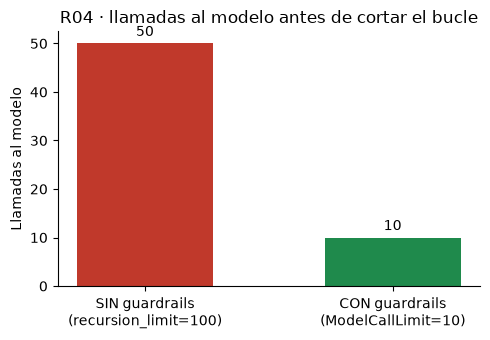

In [5]:
fig, ax = plt.subplots(figsize=(5, 3.5))
etiquetas_barras = ["SIN guardrails\n(recursion_limit=100)", f"CON guardrails\n(ModelCallLimit={g.RUN_LIMIT_MODELO})"]
valores_barras = [modelo_sin.n, modelo_con.n]
barras = ax.bar(etiquetas_barras, valores_barras, color=[COLOR_SIN, COLOR_CON], width=0.55)
ax.bar_label(barras, padding=3)
ax.set_ylabel("Llamadas al modelo")
ax.set_title("R04 · llamadas al modelo antes de cortar el bucle")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 2. Verificador XBRL (R05): extraer y comparar cifras

`extraer_cifras` lee los importes en USD que afirma una respuesta (ignora los porcentajes: docs/09 §4). Ejemplos rápidos, sin modelo ni red:

Guía: [09 §4](../docs/09_skill_guardrails_middleware_xbrl.md)

In [6]:
ejemplos_prosa = [
    "391 billones de dólares",
    "El BPA fue de 2,97 USD por acción, tras el split 10:1 (FY2025, Item 7)",
    "Ingresos de $60,922 millones y 44.301 millones de USD",
    "creció un 14,9 %",  # los porcentajes no cuentan como cifra XBRL
]
for texto in ejemplos_prosa:
    print(f"{texto!r:65s} -> {g.extraer_cifras(texto)}")

'391 billones de dólares'                                         -> [391000000000000.0]
'El BPA fue de 2,97 USD por acción, tras el split 10:1 (FY2025, Item 7)' -> [2.97]
'Ingresos de $60,922 millones y 44.301 millones de USD'           -> [60922000000.0, 44301000000.0]
'creció un 14,9 %'                                                -> []


### Tres casos reales contra el parquet (docs/09 §6, `tests/test_guardrails_verificador.py`)

El "ledger" (`guardrails.libro_hechos`) se construye con llamadas REALES a `get_xbrl_fact` sobre `data/corpus/xbrl_facts.parquet`: no hay
modelo de por medio. Lo que varía en cada caso es la cifra que el modelo *habría* declarado; `verificar_xbrl` la contrasta y repara sin
gastar una segunda llamada al modelo.

1. **Escala mal (NVDA, Revenues FY2024):** el modelo copia el valor sin escalar.
2. **BPA básico confundido con diluido (AAPL FY2024):** el valor declarado es el diluido, pero `concept_xbrl` dice "básico".
3. **Comparativa con orientación invertida (NVDA, EPS FY2025 vs FY2024):** `cifra` y `cifra_base` llegan cambiadas de sitio.

Guía: [09 §5–§6](../docs/09_skill_guardrails_middleware_xbrl.md)

In [7]:
def ledger_real(*consultas):
    """Ledger construido con llamadas REALES a get_xbrl_fact sobre el parquet del corpus (sin red, sin LLM)."""
    msgs = []
    for i, (ticker, fy, concept) in enumerate(consultas):
        args = {"ticker": ticker, "fiscal_year": fy, "concept": concept}
        msgs.append(AIMessage(content="", tool_calls=[{"name": "get_xbrl_fact", "id": f"v{i}", "args": args}]))
        msgs.append(ToolMessage(content=str(get_xbrl_fact.invoke(args)), tool_call_id=f"v{i}", name="get_xbrl_fact"))
    return g.libro_hechos(msgs)


casos = []

# 1. Escala mal: NVDA Revenues FY2024 — el modelo copia el valor "sin escalar" (60.922 en vez de 60.922.000.000)
decl1 = {"respuesta": "x", "fuente": "xbrl", "cifra": 60_922, "unidad": "USD", "ticker": "NVDA", "ejercicio": 2024}
inf1 = g.verificar_xbrl(decl1, ledger_real(("NVDA", 2024, "Revenues")), [])
casos.append({"caso": "1. Escala mal (NVDA Revenues FY2024)",
             "declarado": f"{decl1['cifra']:,} {decl1['unidad']}",
             "verificado": f"{inf1.resp['cifra']:,.0f} {inf1.resp['unidad']}",
             "reparaciones": ", ".join(c for c, _ in inf1.reparaciones), "problemas_sin_resolver": len(inf1.problemas)})

# 2. BPA básico confundido con diluido: AAPL FY2024 (declara "básico" pero el valor es el diluido)
decl2 = {"respuesta": "x", "fuente": "xbrl", "cifra": 6.08, "unidad": "USD/shares", "ticker": "AAPL",
         "ejercicio": 2024, "concept_xbrl": "EarningsPerShareBasic"}
inf2 = g.verificar_xbrl(decl2, ledger_real(("AAPL", 2024, "EarningsPerShareBasic"),
                                           ("AAPL", 2024, "EarningsPerShareDiluted")), [])
casos.append({"caso": "2. BPA básico↔diluido (AAPL FY2024)",
             "declarado": f"{decl2['cifra']} USD/shares · concept={decl2['concept_xbrl']}",
             "verificado": f"{inf2.resp['cifra']} USD/shares · concept={inf2.resp['concept_xbrl']}",
             "reparaciones": ", ".join(c for c, _ in inf2.reparaciones), "problemas_sin_resolver": len(inf2.problemas)})

# 3. Comparativa con orientación invertida: NVDA EPS FY2025 vs FY2024 (cifra/cifra_base cambiadas de sitio)
decl3 = {"respuesta": "x", "fuente": "xbrl", "cifra": 12.05, "cifra_base": 2.97, "unidad": "USD/shares",
         "ticker": "nvidia", "ejercicio": 2024, "ejercicio_base": 2025, "concept_xbrl": "EarningsPerShareBasic"}
inf3 = g.verificar_xbrl(decl3, ledger_real(("NVDA", 2025, "EarningsPerShareBasic"),
                                           ("NVDA", 2024, "EarningsPerShareBasic")), [])
casos.append({"caso": "3. Comparativa invertida (NVDA EPS FY2025 vs FY2024)",
             "declarado": f"cifra={decl3['cifra']}@FY{decl3['ejercicio']} / base={decl3['cifra_base']}@FY{decl3['ejercicio_base']} · ticker={decl3['ticker']}",
             "verificado": f"cifra={inf3.resp['cifra']}@FY{inf3.resp['ejercicio']} / base={inf3.resp['cifra_base']}@FY{inf3.resp['ejercicio_base']} · ticker={inf3.resp['ticker']}",
             "reparaciones": ", ".join(c for c, _ in inf3.reparaciones), "problemas_sin_resolver": len(inf3.problemas)})

tabla_verificador = pd.DataFrame(casos)
assert (tabla_verificador["problemas_sin_resolver"] == 0).all()   # los tres se reparan SIN pedir otra vuelta al modelo
display(tabla_verificador)

,caso,declarado,verificado,reparaciones,problemas_sin_resolver
0,1. Escala mal (NVDA Revenues FY2024),"60,922 USD","60,922,000,000 USD","escala_corregida, cifra_exacta",0
1,2. BPA básico↔diluido (AAPL FY2024),6.08 USD/shares · concept=EarningsPerShareBasic,6.08 USD/shares · concept=EarningsPerShareDiluted,concepto_corregido,0
2,3. Comparativa invertida (NVDA EPS FY2025 vs F...,cifra=12.05@FY2024 / base=2.97@FY2025 · ticker...,cifra=2.97@FY2025 / base=12.05@FY2024 · ticker...,"ticker_normalizado, orientacion_invertida",0


## 3. Honestidad ante huecos (R14): el margen bruto de AMZN

Hueco real del golden (`golden/golden_huecos.jsonl`, `g3-h001`): *"¿Cuál fue el margen bruto de AMZN en el ejercicio fiscal 2025?"*. `AMZN` no
reportó `GrossProfit` en FY2025 — lo confirma `get_xbrl_fact` real, sin modelo de por medio. Un modelo sin guardrails podría derivar un
porcentaje plausible (a partir de ingresos y coste de ventas, que sí existen) y presentarlo como si fuera un dato verificado. La demo
reproduce ese guion (`tests/test_guardrails_middleware.py::test_hueco_con_cifra_derivada_se_degrada_a_ninguna_sin_reintentar`) y, después, el
camino rápido del mismo hueco (`test_camino_rapido_hueco_se_abstiene_sin_segunda_llamada`).

Guía: [09 §1](../docs/09_skill_guardrails_middleware_xbrl.md), fila R14

In [8]:
PREGUNTA_HUECO = "¿Cuál fue el margen bruto de AMZN en el ejercicio fiscal 2025?"
AMZN_GROSS_2025 = {"ticker": "AMZN", "fiscal_year": 2025, "concept": "GrossProfit"}

# Confirmación directa: la herramienta REAL sobre el corpus dice que no lo reportó (sin modelo de por medio)
print(get_xbrl_fact.invoke(AMZN_GROSS_2025))

AMZN no reportó 'GrossProfit' en FY2025. El dato no está en el corpus. Responde fuente='ninguna' y cifra=null; no calcules ni sumes componentes ni uses read_section.


In [9]:
# El modelo de guion consulta el hueco real y, aun así, declara un 50,28 % "verificado contra XBRL".
mensajes_hueco = [
    tc("get_xbrl_fact", AMZN_GROSS_2025, 1),
    respuesta_final(2, cifra=50.28, unidad="%", ticker="AMZN", ejercicio=2025, fuente="ambas",
                    concept_xbrl="GrossProfit", respuesta="El margen bruto de AMZN en FY2025 fue de 50,28 %."),
]
res_hueco, modelo_hueco = correr_agente(mensajes_hueco, middleware=g.middleware_final(camino_rapido=False),
                                        pregunta=PREGUNTA_HUECO)
r_hueco = res_hueco["structured_response"]
guard_hueco = res_hueco.get("guard") or {}

print("El modelo quiso responder :", "'El margen bruto de AMZN en FY2025 fue de 50,28 %.' (fuente='ambas', cifra=50.28)")
print("El guardrail devuelve     :", f"fuente={r_hueco.fuente!r}, cifra={r_hueco.cifra!r}, cifra_base={r_hueco.cifra_base!r}")
print("Respuesta final           :", r_hueco.respuesta)
print(f"Sin segundo turno del modelo (modelo_hueco.n = {modelo_hueco.n}): el hueco es una abstención directa,"
      " no un reintento pagado.")

assert r_hueco.fuente == "ninguna" and r_hueco.cifra is None and r_hueco.cifra_base is None
assert guard_hueco["hueco"] is True and guard_hueco["causa"] == "hueco_no_reportado"
assert modelo_hueco.n == 2

El modelo quiso responder : 'El margen bruto de AMZN en FY2025 fue de 50,28 %.' (fuente='ambas', cifra=50.28)
El guardrail devuelve     : fuente='ninguna', cifra=None, cifra_base=None
Respuesta final           : No reportado en XBRL para AMZN FY2025: el dato no está en el corpus.
Sin segundo turno del modelo (modelo_hueco.n = 2): el hueco es una abstención directa, no un reintento pagado.


In [10]:
# Camino rápido: con una única llamada a get_xbrl_fact coherente con la pregunta, el guardrail
# se abstiene sin ni siquiera pedirle una segunda vuelta al modelo (ahorra tokens y latencia).
res_rapido, modelo_rapido = correr_agente([tc("get_xbrl_fact", AMZN_GROSS_2025, 1)],
                                          middleware=g.middleware_final(camino_rapido=True),
                                          pregunta=PREGUNTA_HUECO)
r_rapido = res_rapido["structured_response"]
print(f"Camino rápido: {modelo_rapido.n} llamada(s) al modelo · fuente={r_rapido.fuente!r} · "
      f"respuesta={r_rapido.respuesta!r}")
assert modelo_rapido.n == 1 and r_rapido.fuente == "ninguna" and r_rapido.cifra is None

Camino rápido: 1 llamada(s) al modelo · fuente='ninguna' · respuesta='No reportado en XBRL para AMZN FY2025: el dato no está en el corpus.'


## 4. Cierre: qué requisitos quedan cubiertos

Resumen de lo demostrado arriba (código sin red) y dónde vive la prueba automatizada correspondiente. Los tests de esta tabla se ejecutan
con `.venv\Scripts\python.exe -m pytest -q tests/test_guardrails_middleware.py tests/test_guardrails_verificador.py` (todos con
`GenericFakeChatModel` o llamadas reales a `get_xbrl_fact` sobre el parquet: sin red, sin OpenRouter).

Guía: [09 §7](../docs/09_skill_guardrails_middleware_xbrl.md)

In [11]:
resumen_requisitos = pd.DataFrame([
    {"requisito": "R04 · tope de llamadas", "qué demuestra este notebook": "§1: bucle infinito cortado por ModelCallLimit(10), respuesta rescatada",
     "test": "tests/test_guardrails_middleware.py (37 tests, incl. test_modelo_que_siempre_pide_herramientas_termina_con_respuesta_rescatada)"},
    {"requisito": "R05 · verificador XBRL", "qué demuestra este notebook": "§2: escala, básico/diluido y comparativa invertida, reparados sin reintento",
     "test": "tests/test_guardrails_verificador.py (25 tests, casos de docs/09 §7 / D15)"},
    {"requisito": "R14 · honestidad ante huecos", "qué demuestra este notebook": "§3: AMZN GrossProfit FY2025 — fuente='ninguna' pese a una cifra derivada",
     "test": "tests/test_guardrails_middleware.py::test_hueco_con_cifra_derivada_se_degrada_a_ninguna_sin_reintentar y test_camino_rapido_hueco_se_abstiene_sin_segunda_llamada"},
])
display(resumen_requisitos)

display(Markdown(
    "**Estado (`CLAUDE.md`):** `guardrails.middleware_final()` está implementado y probado sin red — límites, verificador XBRL, cita "
    "por frase numerada, `fuente` derivada, reparación y camino rápido. Lo que falta, y no es cosa de este notebook, es la **medición "
    "oficial** del sistema `final` sobre el golden completo: se ejecuta con `evaluar(golden_propio.jsonl, etiqueta='final', "
    "sistema='final')` (mismo modelo y `temperature=0` que el baseline congelado), y sus tablas se leen en "
    "[07_sistema_final.ipynb](07_sistema_final.ipynb) en cuanto `resultados/final/resumen.json` exista."))

,requisito,qué demuestra este notebook,test
0,R04 · tope de llamadas,§1: bucle infinito cortado por ModelCallLimit(...,"tests/test_guardrails_middleware.py (37 tests,..."
1,R05 · verificador XBRL,"§2: escala, básico/diluido y comparativa inver...",tests/test_guardrails_verificador.py (25 tests...
2,R14 · honestidad ante huecos,§3: AMZN GrossProfit FY2025 — fuente='ninguna'...,tests/test_guardrails_middleware.py::test_huec...


**Estado (`CLAUDE.md`):** `guardrails.middleware_final()` está implementado y probado sin red — límites, verificador XBRL, cita por frase numerada, `fuente` derivada, reparación y camino rápido. Lo que falta, y no es cosa de este notebook, es la **medición oficial** del sistema `final` sobre el golden completo: se ejecuta con `evaluar(golden_propio.jsonl, etiqueta='final', sistema='final')` (mismo modelo y `temperature=0` que el baseline congelado), y sus tablas se leen en [07_sistema_final.ipynb](07_sistema_final.ipynb) en cuanto `resultados/final/resumen.json` exista.